## BaseLine Model

### Dataset Class

In [1]:
from torch.utils.data import Dataset
import torch
import numpy as np
import pandas as pd

In [2]:
class CustomDataset(Dataset):

  def __init__(self, data_path, tokenizer, max_length):

    self.data = pd.read_csv(data_path)
    self.sentiments = self.data['sentiment'].values
    self.texts = self.data['tweet'].values
    self.tokenizer = tokenizer
    self.max_length = max_length

  def __len__(self):

    return len(self.sentiments)

  def __getitem__(self, index):

    text = self.texts[index]
    inputs = self.tokenizer(text, padding="max_length", truncation=True,
                            max_length=self.max_length, return_tensors="pt")

    input_ids = inputs["input_ids"].squeeze(0)
    attention_mask = inputs["attention_mask"].squeeze(0)

    sentiment = torch.tensor(self.sentiments[index])

    return input_ids, attention_mask, sentiment

### ModelClass

In [3]:
!pip install -U bitsandbytes>=0.46.1

In [4]:
!pip install -U bitsandbytes>=0.46.1 accelerate

In [ ]:
import torch.nn as nn
from transformers import AutoModel, BitsAndBytesConfig
from huggingface_hub import notebook_login

In [ ]:
notebook_login()

In [8]:
class LLM_Classifier(nn.Module):

  def __init__(self, model_name, num_classes):
    super(LLM_Classifier, self).__init__()

    self.num_classes = num_classes
    bnb_config = BitsAndBytesConfig(load_in_8bit=True)

    self.model = AutoModel.from_pretrained(model_name, quantization_config=bnb_config)

    for param in self.model.parameters():
      param.requires_grad = False

    hidden_size = self.model.config.hidden_size
    self.classifier = nn.Linear(hidden_size,num_classes).to(self.model.dtype)

  def forward(self, input_ids, attention_mask):

    outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
    last_token = outputs.last_hidden_state[:,-1,:]
    logits = self.classifier(last_token)
    return logits


### Dataset Loading

In [23]:
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

model_name = 'unsloth/Llama-3.2-3B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

train_dataset = CustomDataset(data_path="/kaggle/input/datasets/aryan7004/sentiment-twitter/twitter_training_3class.csv",tokenizer=tokenizer, max_length=208)
valid_dataset = CustomDataset(data_path="/kaggle/input/datasets/aryan7004/sentiment-twitter/twitter_validation_3class.csv",tokenizer=tokenizer, max_length=208)
test_dataset = CustomDataset(data_path="/kaggle/input/datasets/aryan7004/sentiment-testing-dataset/twitter_testing_3class.csv",tokenizer=tokenizer, max_length=208)


In [24]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers = 2)
val_loader   = DataLoader(valid_dataset, batch_size=64, shuffle=False, num_workers = 2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers = 2)

### Training Script

In [11]:
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
from tqdm.auto import tqdm

In [12]:
learning_rate = 5e-4
num_epochs = 12
num_classes = 3

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LLM_Classifier(model_name=model_name,num_classes=num_classes)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

In [14]:
model.to(device)

LLM_Classifier(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072, padding_idx=128004)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear8bitLt(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear8bitLt(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear8bitLt(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear8bitLt(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear8bitLt(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear8bitLt(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear8bitLt(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
    

In [15]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=learning_rate)

best_val_loss = float("inf")
patience = 3
patience_counter = 0
min_delta = 1e-4

In [16]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [17]:
for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")

    for step, (input_ids, attention_mask, labels) in enumerate(train_bar):
        #print(f"Max ID: {input_ids.max()}, Min ID: {input_ids.min()}")

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.long().to(device)


        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        if step % 10 == 0:
           train_bar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1} Validation")

    with torch.no_grad():
        for input_ids, attention_mask, labels in val_bar:

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.long().to(device)

            logits = model(input_ids, attention_mask)

            loss = criterion(logits, labels)
            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")

    if avg_val_loss < best_val_loss - min_delta:
       best_val_loss = avg_val_loss
       patience_counter = 0
       torch.save(model.state_dict(), "best_model.pt")
    else:
       patience_counter += 1
       print(f"Early stopping counter: {patience_counter}/{patience}")

       if patience_counter >= patience:
          print("Early stopping triggered")
          break

Epoch 1 Training:   0%|          | 0/142 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Epoch 1 Validation:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.8872, Val Loss = 0.8717, Val Acc = 0.6003


Epoch 2 Training:   0%|          | 0/142 [00:00<?, ?it/s]

...

Epoch 5: Train Loss = 0.6499, Val Loss = 0.8127, Val Acc = 0.6441
Early stopping counter: 2/3


Epoch 6 Training:   0%|          | 0/142 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e171a9a6520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    Exception ignored in: self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7e171a9a6520>

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
if w.is_alive():
      self._shutdown_workers() 
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
     if w.is_alive(): Exception ignored in: 
^Exception ignored in: ^ <function _MultiProcessingDataLoaderIter.__del__ at 0x7e171a9a6520>
^<function _MultiProcessingDataLoaderIter.__del__ at 0x7e171a9a6520> 
Traceback (most recent cal

Epoch 6 Validation:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 6: Train Loss = 0.6330, Val Loss = 0.8274, Val Acc = 0.6401
Early stopping counter: 3/3
Early stopping triggered


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in tqdm(dataloader, desc="Evaluating"):

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            logits = outputs if isinstance(outputs, torch.Tensor) else outputs.logits

            logits = logits.float()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.detach().cpu().float().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted'
    )

    try:
        auroc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    except:
        auroc = None

    class_names = ["Negative", "Neutral", "Positive"]

    cls_report = classification_report(all_labels, all_preds, target_names=class_names)

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    print("\nClassification Report:\n")
    print(cls_report)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auroc": auroc,
        "confusion_matrix": cm,
        "classification_report": cls_report
    }


Evaluating: 100%|██████████| 18/18 [01:41<00:00,  5.66s/it]


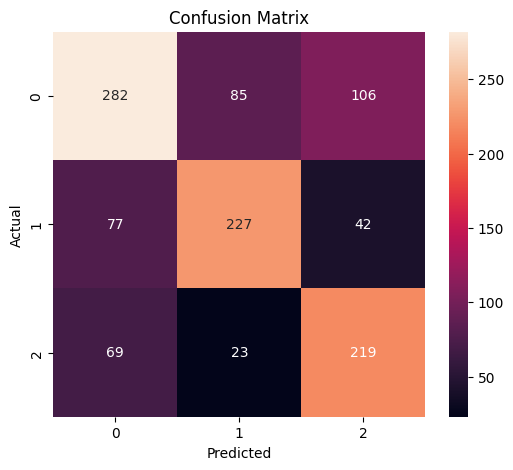


Classification Report:

              precision    recall  f1-score   support

    Negative       0.66      0.60      0.63       473
     Neutral       0.68      0.66      0.67       346
    Positive       0.60      0.70      0.65       311

    accuracy                           0.64      1130
   macro avg       0.64      0.65      0.65      1130
weighted avg       0.65      0.64      0.64      1130



In [34]:
metrics = evaluate(model, test_loader, device)

In [35]:
print(f"""
Accuracy:  {metrics['accuracy']:.4f}
Precision: {metrics['precision']:.4f}
Recall:    {metrics['recall']:.4f}
F1 Score:  {metrics['f1']:.4f}
AUROC:     {f"{metrics['auroc']:.4f}" if metrics['auroc'] is not None else "N/A"}
""")


Accuracy:  0.6442
Precision: 0.6475
Recall:    0.6442
F1 Score:  0.6439
AUROC:     0.8195

